# MC Dropout Selective Prediction: Bootstrap and Diagnostics

This notebook is MC Dropout-only.

Contents:
1. Deterministic model MC Dropout inference
2. Uncertainty metrics and deferral policies
3. Bootstrap confidence intervals
4. Diagnostic figures




In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import gc
import random
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

from modules.uncertaintybis import (
    compute_all_uncertainties,
    build_deferral_policies,
    selective_prediction_eval,
    compute_ausc,
    bootstrap_ausc,
    bootstrap_selective_prediction,
    compute_epistemic_profiles,
    compute_error_epistemic_signatures,
    compute_confusion_epistemic_matrix,
)
from modules.data_pipeline import (
    load_and_combine_datasets,
    patient_level_split,
    make_dataset,
)

# GPU config
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f'Enabled memory growth for {len(gpus)} GPU(s)')

SEED = 42

def set_seed(seed=SEED):
    os.environ['PYTHONHASHSEED'] = str(seed)
    tf.keras.backend.clear_session()
    gc.collect()
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    tf.keras.utils.set_random_seed(seed)

print(f'TensorFlow: {tf.__version__}')
print(f'GPUs: {tf.config.list_physical_devices("GPU")}')


2026-02-22 13:20:30.081066: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-22 13:20:30.081104: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-22 13:20:30.082088: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Enabled memory growth for 1 GPU(s)
TensorFlow: 2.15.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Configuration


In [2]:
IMG_SIZE = 256
BATCH_SIZE = 32
MC_SAMPLES = 30
CRITICAL_CLASSES = [2, 3]
SAFE_CLASSES = [0, 1]
COVERAGE_LEVELS = [0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 1.00]


## 2. Load Data and Run MC Dropout


## 3.  Reload Checkpoint (Optional)


In [4]:
# Reload from disk to skip inference
mc_dropout_preds = np.load(f'results_stable/mcdo_det_preds_{MC_SAMPLES}samples.npy')
y_true_mc = np.load('results_stable/mcdo_det_y_true.npy')

mc_dropout_metrics = compute_all_uncertainties(
    mc_dropout_preds,
    critical_classes=CRITICAL_CLASSES,
    safe_classes=SAFE_CLASSES,
)

# Compute predicted class labels from MC dropout samples
# Take mean across MC samples (axis=0), then argmax across classes (axis=1)
mc_dropout_y_pred = np.argmax(mc_dropout_preds.mean(axis=0), axis=1)

In [5]:
from sklearn.metrics import roc_auc_score
import numpy as np

mc_dropout_mu = mc_dropout_metrics["mu"]  # [N, K]
mc_dropout_p_critical = mc_dropout_mu[:, CRITICAL_CLASSES].sum(axis=1)

def critical_auroc_at_coverage(y_true, p_critical, uncertainty_scores, coverage, critical_classes):
    n_keep = max(1, int(round(coverage * len(y_true))))
    keep_idx = np.argsort(uncertainty_scores)[:n_keep]
    y_bin = np.isin(y_true[keep_idx], critical_classes).astype(int)
    if np.unique(y_bin).size < 2:
        return np.nan
    return roc_auc_score(y_bin, p_critical[keep_idx])


In [6]:
from sklearn.metrics import roc_auc_score
import numpy as np

# Mean class probabilities from MC Dropout
mu = mc_dropout_metrics.get('mu', mc_dropout_preds.mean(axis=0))  # shape [N, K]

# 1) Multiclass AUROC (macro, one-vs-rest)
auroc_macro = roc_auc_score(y_true_mc, mu, multi_class='ovr', average='macro')
print(f'MC Dropout AUROC (macro OVR): {auroc_macro:.4f}')

# 2) Critical-vs-safe AUROC (clinical boundary metric)
y_true_bin = np.isin(y_true_mc, CRITICAL_CLASSES).astype(int)
p_critical = mu[:, CRITICAL_CLASSES].sum(axis=1)


MC Dropout AUROC (macro OVR): 0.8577


## 4. Sanity Checks and Policy Evaluation


In [7]:
from scipy.stats import pearsonr, spearmanr

sum_Ck = mc_dropout_metrics['C_k'].sum(axis=1)
mi_scores = mc_dropout_metrics['MI']

r_pearson, _ = pearsonr(sum_Ck, mi_scores)
r_spearman, _ = spearmanr(sum_Ck, mi_scores)
print('Diagnostic 1: decomposition consistency')
print(f'  Pearson r(sum C_k, MI):  {r_pearson:.4f}')
print(f'  Spearman r(sum C_k, MI): {r_spearman:.4f}')

rho_k = mc_dropout_metrics['rho_k']
print('Diagnostic 2: skewness reliability')
for k in range(4):
    median_rho = np.median(rho_k[:, k])
    pct_reliable = np.mean(rho_k[:, k] < 0.3) * 100
    print(f'  Grade {k}: median rho_k={median_rho:.4f}, reliable(<0.3)={pct_reliable:.1f}%')

y_pred = mc_dropout_y_pred
cm = confusion_matrix(y_true_mc, y_pred)
print('Diagnostic 3: confusion matrix')
print(cm)

crit = np.isin(y_true_mc, CRITICAL_CLASSES)
pred_safe = ~np.isin(y_pred, CRITICAL_CLASSES)
boundary_errors = np.sum(crit & pred_safe)
within_crit_errors = np.sum(crit & ~pred_safe & (y_true_mc != y_pred))
total_crit_errors = np.sum(crit & (y_true_mc != y_pred))

print('Critical sample errors:')
print(f'  Boundary crossings (critical -> safe): {boundary_errors}')
print(f'  Within-critical errors:                {within_crit_errors}')
print(f'  Total critical errors:                 {total_crit_errors}')

C_k = mc_dropout_metrics['C_k']
print('Diagnostic 4: C_k statistics')
for k in range(4):
    print(f'  C_{k}: mean={C_k[:, k].mean():.6f}, max={C_k[:, k].max():.4f}, std={C_k[:, k].std():.6f}')

entropy = mc_dropout_metrics['entropy']
C_crit_max = mc_dropout_metrics['C_critical_max']
r_ent, _ = pearsonr(entropy, C_crit_max)
print(f'Diagnostic 5: r(Entropy, C_critical_max) = {r_ent:.4f}')

Diagnostic 1: decomposition consistency
  Pearson r(sum C_k, MI):  0.9642
  Spearman r(sum C_k, MI): 0.9894
Diagnostic 2: skewness reliability
  Grade 0: median rho_k=0.0133, reliable(<0.3)=87.6%
  Grade 1: median rho_k=0.1296, reliable(<0.3)=71.7%
  Grade 2: median rho_k=0.2642, reliable(<0.3)=54.2%
  Grade 3: median rho_k=1.1246, reliable(<0.3)=22.4%
Diagnostic 3: confusion matrix
[[5458    7  111    8]
 [ 463   42   77    5]
 [ 541   13  685   83]
 [  31    1  159  264]]
Critical sample errors:
  Boundary crossings (critical -> safe): 586
  Within-critical errors:                242
  Total critical errors:                 828
Diagnostic 4: C_k statistics
  C_0: mean=0.007332, max=0.2267, std=0.018227
  C_1: mean=0.006275, max=0.1543, std=0.009695
  C_2: mean=0.011800, max=0.4077, std=0.016284
  C_3: mean=0.005689, max=0.3689, std=0.014759
Diagnostic 5: r(Entropy, C_critical_max) = 0.4299


In [8]:
mc_dropout_policies = build_deferral_policies(mc_dropout_metrics)
print(f'Number of MC Dropout policies: {len(mc_dropout_policies)}')

print('MC Dropout uncertainty summary:')
print(f'  Mean MI:              {mc_dropout_metrics["MI"].mean():.4f}')
print(f'  Mean Entropy:         {mc_dropout_metrics["entropy"].mean():.4f}')
print(f'  Mean C_critical_max:  {mc_dropout_metrics["C_critical_max"].mean():.4f}')
print(f'  Mean MaxProb score:   {(1 - mc_dropout_metrics["maxprob"]).mean():.4f}')


Number of MC Dropout policies: 10
MC Dropout uncertainty summary:
  Mean MI:              0.0274
  Mean Entropy:         0.4324
  Mean C_critical_max:  0.0140
  Mean MaxProb score:   0.8520


In [9]:
print('MC Dropout @ 80% coverage')
print('-' * 90)
print(f'{"Policy":<20} {"Accuracy":>10} {"Crit FNR":>10} {"AUSC":>10}')
print('-' * 90)

mc_dropout_results_80 = {}
for name, scores in mc_dropout_policies.items():
    results = selective_prediction_eval(
        y_true_mc,
        mc_dropout_y_pred,
        scores,
        [0.80],
        critical_classes=CRITICAL_CLASSES,
    )
    ausc_fnr, _, _ = compute_ausc(
        y_true_mc,
        mc_dropout_y_pred,
        scores,
        CRITICAL_CLASSES,
        metric='critical_fnr',
    )
    r = results[0]
    mc_dropout_results_80[name] = {
        'accuracy': r['accuracy'],
        'critical_fnr': r['critical_fnr'],
        'ausc': ausc_fnr,
    }
    print(f'{name:<20} {r["accuracy"]:>10.4f} {r["critical_fnr"]:>10.4f} {ausc_fnr:>10.4f}')

print('-' * 90)


MC Dropout @ 80% coverage
------------------------------------------------------------------------------------------
Policy                 Accuracy   Crit FNR       AUSC
------------------------------------------------------------------------------------------
Entropy                  0.8712     0.2924     0.2488
MI                       0.8633     0.4564     0.4229
MaxProb                  0.8736     0.3383     0.2671
Var_critical             0.8677     0.4481     0.4216
Sale_EU_global           0.8692     0.4061     0.3626
Sale_EU_critical         0.8652     0.5244     0.4608
OvA_MI                   0.8610     0.5542     0.5238
C_critical_sum           0.8600     0.4022     0.4339
C_critical_max           0.8534     0.3881     0.4174
CBEC                     0.8668     0.3138     0.1962
------------------------------------------------------------------------------------------


In [10]:
for name in ['C_critical_max', 'Entropy', 'MI']:
    if name not in mc_dropout_policies:
        continue

    scores = mc_dropout_policies[name]
    ausc_fnr, _, _ = compute_ausc(
        y_true_mc,
        mc_dropout_y_pred,
        scores,
        CRITICAL_CLASSES,
        metric='critical_fnr',
    )
    ausc_err, _, _ = compute_ausc(
        y_true_mc,
        mc_dropout_y_pred,
        scores,
        CRITICAL_CLASSES,
        metric='critical_err',
    )
    print(f'{name:<20} AUSC(true FNR)={ausc_fnr:.4f}  AUSC(critical err)={ausc_err:.4f}')


C_critical_max       AUSC(true FNR)=0.4174  AUSC(critical err)=0.4570
Entropy              AUSC(true FNR)=0.2488  AUSC(critical err)=0.3298
MI                   AUSC(true FNR)=0.4229  AUSC(critical err)=0.4643


## 5. Bootstrap Confidence Intervals


In [11]:
print('Running AUSC bootstrap for MC Dropout policies...')
boot_mc_dropout = bootstrap_ausc(
    y_true_mc,
    mc_dropout_y_pred,
    mc_dropout_policies,
    critical_classes=CRITICAL_CLASSES,
    n_bootstrap=200,
    seed=42,
    metric='critical_fnr',
)

print('MC Dropout bootstrap results (200 iterations)')
print('=' * 90)
print(f'{"Policy":<20} {"Mean":>8} {"Std":>8} {"CI_lower":>10} {"CI_upper":>10} {"Win%":>8}')
print('-' * 90)

sorted_mc_dropout = sorted(boot_mc_dropout['summary'].items(), key=lambda x: x[1]['mean'])
for name, s in sorted_mc_dropout:
    win_pct = boot_mc_dropout['ranking_stability'].get(name, 0) * 100
    marker = '*' if name in ['C_critical_max', 'CBEC'] else ' '
    print(f'{marker} {name:<19} {s["mean"]:>8.4f} {s["std"]:>8.4f} {s["ci_lower"]:>10.4f} {s["ci_upper"]:>10.4f} {win_pct:>7.1f}%')

print('=' * 90)


Running AUSC bootstrap for MC Dropout policies...
Running bootstrap with 200 iterations...
  Bootstrap 200/200
  Bootstrap complete!
MC Dropout bootstrap results (200 iterations)
Policy                   Mean      Std   CI_lower   CI_upper     Win%
------------------------------------------------------------------------------------------
* CBEC                  0.1971   0.0123     0.1729     0.2223   100.0%
  Entropy               0.2492   0.0167     0.2152     0.2841     0.0%
  MaxProb               0.2677   0.0174     0.2339     0.3042     0.0%
  Sale_EU_global        0.3638   0.0224     0.3233     0.4071     0.0%
* C_critical_max        0.4191   0.0251     0.3742     0.4684     0.0%
  Var_critical          0.4236   0.0259     0.3772     0.4736     0.0%
  MI                    0.4247   0.0242     0.3810     0.4737     0.0%
  C_critical_sum        0.4360   0.0257     0.3902     0.4857     0.0%
  Sale_EU_critical      0.4627   0.0269     0.4157     0.5185     0.0%
  OvA_MI             

In [12]:
from modules.uncertaintybis import bootstrap_selective_prediction

boot_fnr = bootstrap_selective_prediction(
    y_true=y_true_mc,
    y_pred=y_pred,
    uncertainty_scores_dict=mc_dropout_policies,   # dict: name -> uncertainty scores
    coverage=0.80,                      # operating point
    critical_classes=CRITICAL_CLASSES,
    n_bootstrap=200,
    seed=42,
)

for name, stats in sorted(boot_fnr.items(), key=lambda x: x[1]["critical_fnr"]["mean"]):
    s = stats["critical_fnr"]
    print(f"{name:20s} FNR={s['mean']:.4f}±{s['std']:.4f}  CI95=[{s['ci_lower']:.4f}, {s['ci_upper']:.4f}]")


Running bootstrap at coverage=0.80 with 200 iterations...
  Bootstrap 200/200
  Bootstrap complete!
Entropy              FNR=0.2937±0.0142  CI95=[0.2670, 0.3199]
CBEC                 FNR=0.3158±0.0149  CI95=[0.2866, 0.3406]
MaxProb              FNR=0.3395±0.0158  CI95=[0.3082, 0.3663]
C_critical_max       FNR=0.3901±0.0167  CI95=[0.3618, 0.4229]
C_critical_sum       FNR=0.4039±0.0169  CI95=[0.3741, 0.4363]
Sale_EU_global       FNR=0.4099±0.0175  CI95=[0.3741, 0.4415]
Var_critical         FNR=0.4514±0.0179  CI95=[0.4147, 0.4812]
MI                   FNR=0.4591±0.0190  CI95=[0.4213, 0.4933]
Sale_EU_critical     FNR=0.5266±0.0185  CI95=[0.4870, 0.5627]
OvA_MI               FNR=0.5564±0.0201  CI95=[0.5155, 0.5919]


In [13]:

import numpy as np
from modules.uncertaintybis import selective_prediction_eval

def bootstrap_selective_prediction_with_samples(
    y_true, y_pred, uncertainty_scores_dict, coverage, critical_classes,
    n_bootstrap=200, seed=42
):
    rng = np.random.RandomState(seed)
    N = len(y_true)

    policy_names = list(uncertainty_scores_dict.keys())
    results = {
        name: {"accuracy": [], "critical_fnr": [], "critical_err": [], "f1_macro": []}
        for name in policy_names
    }

    for _ in range(n_bootstrap):
        idx = rng.choice(N, size=N, replace=True)
        yt_b, yp_b = y_true[idx], y_pred[idx]

        for name, scores in uncertainty_scores_dict.items():
            scores_b = scores[idx]
            r = selective_prediction_eval(
                yt_b, yp_b, scores_b, [coverage], critical_classes=critical_classes
            )[0]

            results[name]["accuracy"].append(r["accuracy"])
            results[name]["f1_macro"].append(r["f1_macro"])
            if r["critical_n"] > 0:
                results[name]["critical_fnr"].append(r["critical_fnr"])
                results[name]["critical_err"].append(r["critical_err"])
            else:
                results[name]["critical_fnr"].append(np.nan)
                results[name]["critical_err"].append(np.nan)

    summary = {}
    for name in policy_names:
        summary[name] = {}
        for metric in ["accuracy", "critical_fnr", "critical_err", "f1_macro"]:
            s = np.array(results[name][metric], dtype=float)
            summary[name][metric] = {
                "mean": float(np.nanmean(s)),
                "std": float(np.nanstd(s)),
                "ci_lower": float(np.nanpercentile(s, 2.5)),
                "ci_upper": float(np.nanpercentile(s, 97.5)),
                "samples": s,
            }
    return summary

# Recompute MC-dropout bootstrap with stored samples
boot_mc_dropout_80 = bootstrap_selective_prediction_with_samples(
    y_true=y_true_mc,
    y_pred=mc_dropout_y_pred,
    uncertainty_scores_dict=mc_dropout_policies,
    coverage=0.80,
    critical_classes=CRITICAL_CLASSES,
    n_bootstrap=200,
    seed=42
)

# Significance check
entropy_fnr_samples = boot_mc_dropout_80["Entropy"]["critical_fnr"]["samples"]
cbec_fnr_samples = boot_mc_dropout_80["CBEC"]["critical_fnr"]["samples"]
valid = np.isfinite(entropy_fnr_samples) & np.isfinite(cbec_fnr_samples)
p_entropy_better = np.mean(entropy_fnr_samples[valid] < cbec_fnr_samples[valid])
print(f"P(Entropy FNR < CBEC FNR) = {p_entropy_better:.3f}")
print(f"P(CBEC FNR < Entropy FNR) = {1 - p_entropy_better:.3f}")


P(Entropy FNR < CBEC FNR) = 0.995
P(CBEC FNR < Entropy FNR) = 0.005


In [14]:
print('Running 80% coverage bootstrap for MC Dropout policies...')
boot_mc_dropout_80 = bootstrap_selective_prediction(
    y_true_mc,
    mc_dropout_y_pred,
    mc_dropout_policies,
    coverage=0.80,
    critical_classes=CRITICAL_CLASSES,
    n_bootstrap=200,
    seed=42,
)

print('80% coverage bootstrap summary')
print('=' * 95)
print(f'{"Policy":<20} {"Accuracy":>15} {"Crit FNR":>18} {"Macro F1":>18}')
print('-' * 95)

for name, b in sorted(boot_mc_dropout_80.items(), key=lambda x: x[1]['critical_fnr']['mean']):
    acc_str = f'{b["accuracy"]["mean"]:.4f}+/-{b["accuracy"]["std"]:.4f}'
    fnr_str = f'{b["critical_fnr"]["mean"]:.4f}+/-{b["critical_fnr"]["std"]:.4f}'
    f1_str = f'{b["f1_macro"]["mean"]:.4f}+/-{b["f1_macro"]["std"]:.4f}'
    marker = '*' if name in ['C_critical_max', 'CBEC'] else ' '
    print(f'{marker} {name:<19} {acc_str:>15} {fnr_str:>18} {f1_str:>18}')

print('=' * 95)


Running 80% coverage bootstrap for MC Dropout policies...
Running bootstrap at coverage=0.80 with 200 iterations...
  Bootstrap 200/200
  Bootstrap complete!
80% coverage bootstrap summary
Policy                      Accuracy           Crit FNR           Macro F1
-----------------------------------------------------------------------------------------------
  Entropy             0.8714+/-0.0043    0.2937+/-0.0142    0.5991+/-0.0100
* CBEC                0.8668+/-0.0041    0.3158+/-0.0149    0.5669+/-0.0090
  MaxProb             0.8737+/-0.0043    0.3395+/-0.0158    0.6070+/-0.0094
* C_critical_max      0.8537+/-0.0043    0.3901+/-0.0167    0.5630+/-0.0104
  C_critical_sum      0.8599+/-0.0041    0.4039+/-0.0169    0.5790+/-0.0100
  Sale_EU_global      0.8695+/-0.0041    0.4099+/-0.0175    0.5783+/-0.0088
  Var_critical        0.8679+/-0.0042    0.4514+/-0.0179    0.5832+/-0.0098
  MI                  0.8635+/-0.0041    0.4591+/-0.0190    0.5518+/-0.0085
  Sale_EU_critical    0.8656+/-0

## 6. Diagnostic Figures

### 6.1 Epistemic Profiles


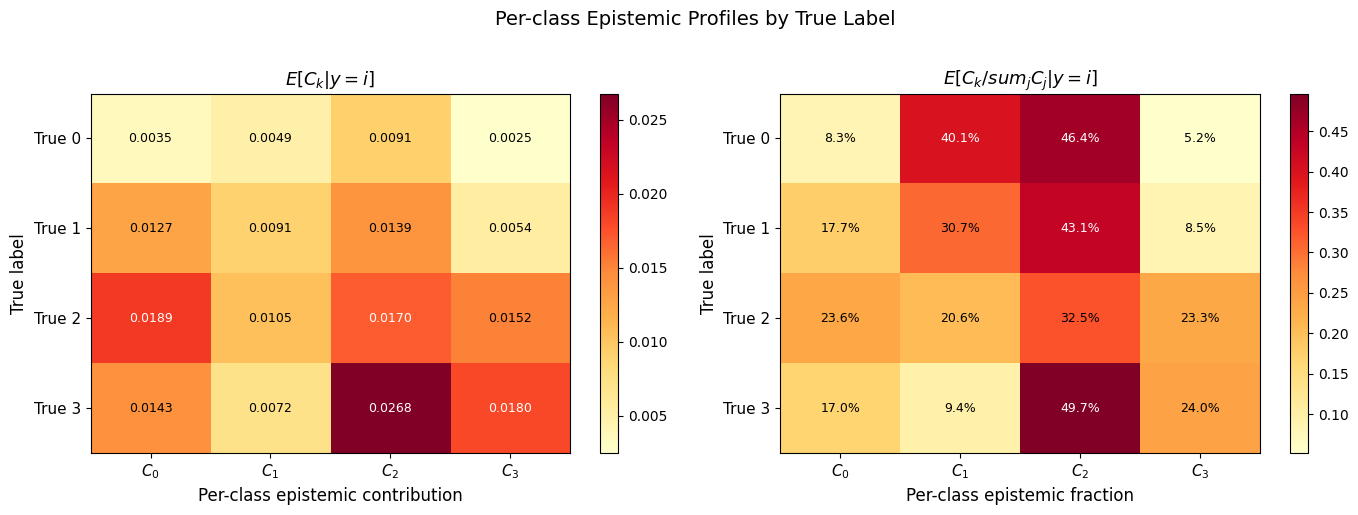

In [15]:
C_k = mc_dropout_metrics['C_k']
profiles = compute_epistemic_profiles(C_k, y_true_mc, normalize=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
im = ax.imshow(profiles['mean'], cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(4))
ax.set_xticklabels([f'$C_{{{k}}}$' for k in range(4)], fontsize=11)
ax.set_yticks(range(4))
ax.set_yticklabels([f'True {k}' for k in range(4)], fontsize=11)
ax.set_xlabel('Per-class epistemic contribution', fontsize=12)
ax.set_ylabel('True label', fontsize=12)
ax.set_title(r'$E[C_k | y = i]$', fontsize=13)
for i in range(4):
    for j in range(4):
        val = profiles['mean'][i, j]
        color = 'white' if val > profiles['mean'].max() * 0.6 else 'black'
        ax.text(j, i, f'{val:.4f}', ha='center', va='center', fontsize=9, color=color)
plt.colorbar(im, ax=ax)

ax = axes[1]
im2 = ax.imshow(profiles['mean_normalized'], cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(4))
ax.set_xticklabels([f'$C_{{{k}}}$' for k in range(4)], fontsize=11)
ax.set_yticks(range(4))
ax.set_yticklabels([f'True {k}' for k in range(4)], fontsize=11)
ax.set_xlabel('Per-class epistemic fraction', fontsize=12)
ax.set_ylabel('True label', fontsize=12)
ax.set_title(r'$E[C_k / sum_j C_j | y = i]$', fontsize=13)
for i in range(4):
    for j in range(4):
        val = profiles['mean_normalized'][i, j]
        color = 'white' if val > 0.35 else 'black'
        ax.text(j, i, f'{val:.1%}', ha='center', va='center', fontsize=9, color=color)
plt.colorbar(im2, ax=ax)

plt.suptitle('Per-class Epistemic Profiles by True Label', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


### 6.2 Error Signatures


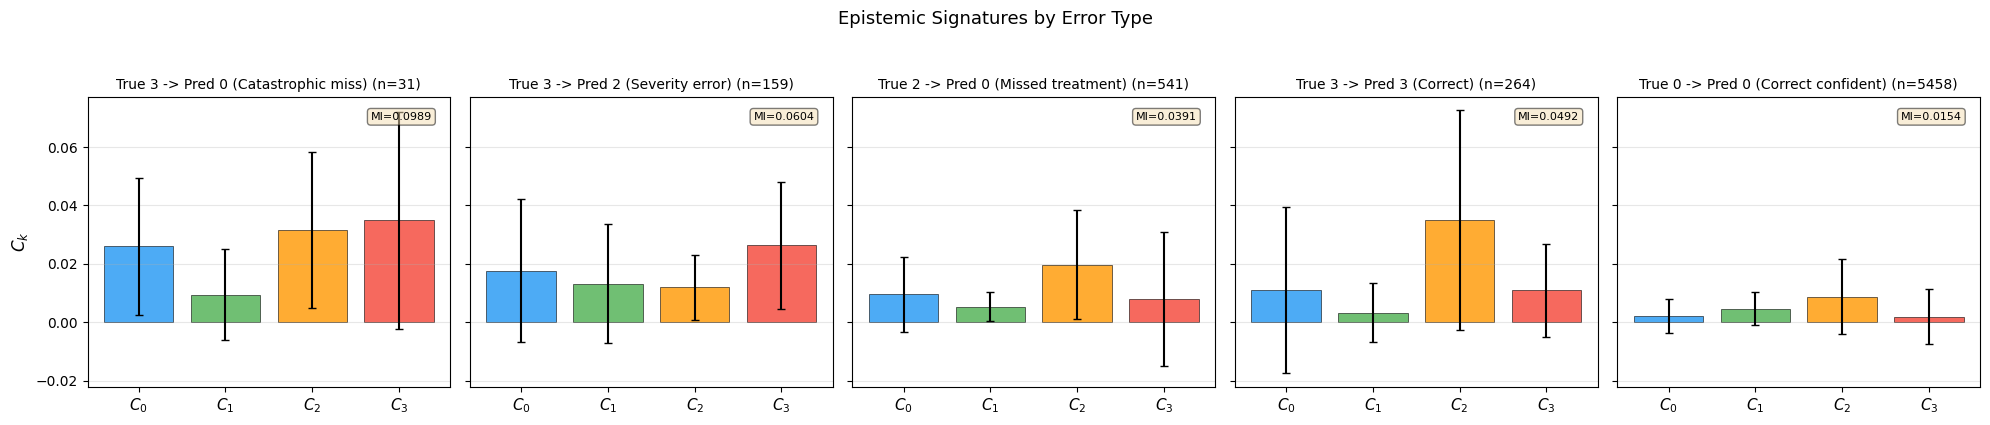

In [16]:
sigs = compute_error_epistemic_signatures(
    C_k,
    y_true_mc,
    mc_dropout_y_pred,
    mi=mc_dropout_metrics['MI'],
)

error_types = [
    ((3, 0), 'True 3 -> Pred 0 (Catastrophic miss)'),
    ((3, 2), 'True 3 -> Pred 2 (Severity error)'),
    ((2, 0), 'True 2 -> Pred 0 (Missed treatment)'),
    ((3, 3), 'True 3 -> Pred 3 (Correct)'),
    ((0, 0), 'True 0 -> Pred 0 (Correct confident)'),
]
error_types = [(pair, label) for pair, label in error_types if pair in sigs['mean']]

fig, axes = plt.subplots(1, len(error_types), figsize=(4 * len(error_types), 4), sharey=True)
if len(error_types) == 1:
    axes = [axes]

colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']
class_labels = [f'$C_{{{k}}}$' for k in range(4)]

for idx, ((i, j), label) in enumerate(error_types):
    ax = axes[idx]
    ck_mean = sigs['mean'][(i, j)]
    ck_std = sigs['std'][(i, j)]
    n = sigs['count'][(i, j)]
    mi_mean = sigs['mean_mi'][(i, j)] if sigs['mean_mi'] else None

    ax.bar(range(4), ck_mean, yerr=ck_std, color=colors, alpha=0.8, capsize=3, edgecolor='black', linewidth=0.5)
    ax.set_xticks(range(4))
    ax.set_xticklabels(class_labels, fontsize=11)
    ax.set_title(f'{label} (n={n})', fontsize=10)
    if idx == 0:
        ax.set_ylabel(r'$C_k$', fontsize=12)
    ax.grid(True, alpha=0.3, axis='y')

    if mi_mean is not None:
        ax.text(
            0.95,
            0.95,
            f'MI={mi_mean:.4f}',
            transform=ax.transAxes,
            ha='right',
            va='top',
            fontsize=8,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.5),
        )

plt.suptitle('Epistemic Signatures by Error Type', fontsize=13, y=1.05)
plt.tight_layout()
plt.show()


### 6.3 Epistemic Confusion Matrix


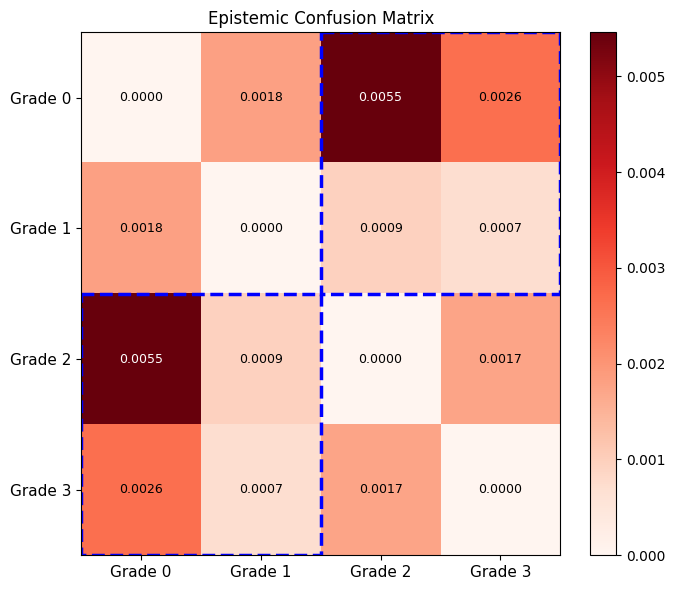

Epistemic Confusion Matrix:
Rows/Cols = Grade 0, 1, 2, 3
[[0.     0.0018 0.0055 0.0026]
 [0.0018 0.     0.0009 0.0007]
 [0.0055 0.0009 0.     0.0017]
 [0.0026 0.0007 0.0017 0.    ]]
Cross-boundary total (S x C): 0.0098
Within-safe total (S x S):    0.0036
Within-critical total (C x C): 0.0035


In [17]:
epi_conf = compute_confusion_epistemic_matrix(C_k, mc_dropout_metrics['corr'])

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(epi_conf, cmap='Reds', aspect='auto')

ax.set_xticks(range(4))
ax.set_xticklabels([f'Grade {k}' for k in range(4)], fontsize=11)
ax.set_yticks(range(4))
ax.set_yticklabels([f'Grade {k}' for k in range(4)], fontsize=11)
ax.set_title('Epistemic Confusion Matrix', fontsize=12)

for i in range(4):
    for j in range(4):
        val = epi_conf[i, j]
        color = 'white' if val > epi_conf.max() * 0.5 else 'black'
        ax.text(j, i, f'{val:.4f}', ha='center', va='center', fontsize=9, color=color)

import matplotlib.patches as patches
rect1 = patches.Rectangle((1.5, -0.5), 2, 2, linewidth=2.5, edgecolor='blue', facecolor='none', linestyle='--')
ax.add_patch(rect1)
rect2 = patches.Rectangle((-0.5, 1.5), 2, 2, linewidth=2.5, edgecolor='blue', facecolor='none', linestyle='--')
ax.add_patch(rect2)

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

print('Epistemic Confusion Matrix:')
print('Rows/Cols = Grade 0, 1, 2, 3')
print(np.array2string(epi_conf, precision=4, suppress_small=True))
print(f'Cross-boundary total (S x C): {epi_conf[:2, 2:].sum():.4f}')
print(f'Within-safe total (S x S):    {epi_conf[:2, :2].sum():.4f}')
print(f'Within-critical total (C x C): {epi_conf[2:, 2:].sum():.4f}')


## 7. Paper-Ready Outputs


In [18]:
groups = {
    'Entropy': 'Scalar',
    'MI': 'Scalar',
    'MaxProb': 'Scalar',
    'Sale_EU_global': 'Per-class variance',
    'Sale_EU_critical': 'Per-class variance',
    'Var_critical': 'Per-class variance',
    'OvA_MI': 'Per-class MI',
    'C_critical_sum': 'Per-class C_k (ours)',
    'C_critical_max': 'Per-class C_k (ours)',
    'Boundary_MI': 'Boundary-aware',
    'CBEC': 'Boundary-aware',
}

display_order = [
    'Entropy', 'MI', 'MaxProb',
    'Var_critical', 'Sale_EU_global', 'Sale_EU_critical',
    'OvA_MI', 'C_critical_sum', 'C_critical_max',
    'Boundary_MI', 'CBEC',
]

print('=' * 105)
print('TABLE FOR PAPER: MC Dropout Selective Prediction @ 80% Coverage (Critical = {2, 3})')
print('=' * 105)
print(f'{"Group":<24} {"Policy":<20} {"AUSC":>14} {"CritFNR@80%":>20} {"Acc@80%":>18}')
print('-' * 105)

for name in display_order:
    if name not in boot_mc_dropout['summary']:
        continue

    g = groups.get(name, '?')
    s = boot_mc_dropout['summary'][name]
    ausc_str = f'{s["mean"]:.4f}+/-{s["std"]:.4f}'

    if name in boot_mc_dropout_80:
        b = boot_mc_dropout_80[name]
        fnr_str = f'{b["critical_fnr"]["mean"]:.4f}+/-{b["critical_fnr"]["std"]:.4f}'
        acc_str = f'{b["accuracy"]["mean"]:.4f}+/-{b["accuracy"]["std"]:.4f}'
    else:
        fnr_str = '---'
        acc_str = '---'

    marker = '*' if name in ['C_critical_max', 'CBEC'] else ' '
    print(f'{marker} {g:<23} {name:<20} {ausc_str:>14} {fnr_str:>20} {acc_str:>18}')

print('=' * 105)


TABLE FOR PAPER: MC Dropout Selective Prediction @ 80% Coverage (Critical = {2, 3})
Group                    Policy                         AUSC          CritFNR@80%            Acc@80%
---------------------------------------------------------------------------------------------------------
  Scalar                  Entropy              0.2492+/-0.0167      0.2937+/-0.0142    0.8714+/-0.0043
  Scalar                  MI                   0.4247+/-0.0242      0.4591+/-0.0190    0.8635+/-0.0041
  Scalar                  MaxProb              0.2677+/-0.0174      0.3395+/-0.0158    0.8737+/-0.0043
  Per-class variance      Var_critical         0.4236+/-0.0259      0.4514+/-0.0179    0.8679+/-0.0042
  Per-class variance      Sale_EU_global       0.3638+/-0.0224      0.4099+/-0.0175    0.8695+/-0.0041
  Per-class variance      Sale_EU_critical     0.4627+/-0.0269      0.5266+/-0.0185    0.8656+/-0.0041
  Per-class MI            OvA_MI               0.5259+/-0.0284      0.5564+/-0.0201    0.86

/tmp/ipykernel_3999072/716620169.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True, showmeans=True)


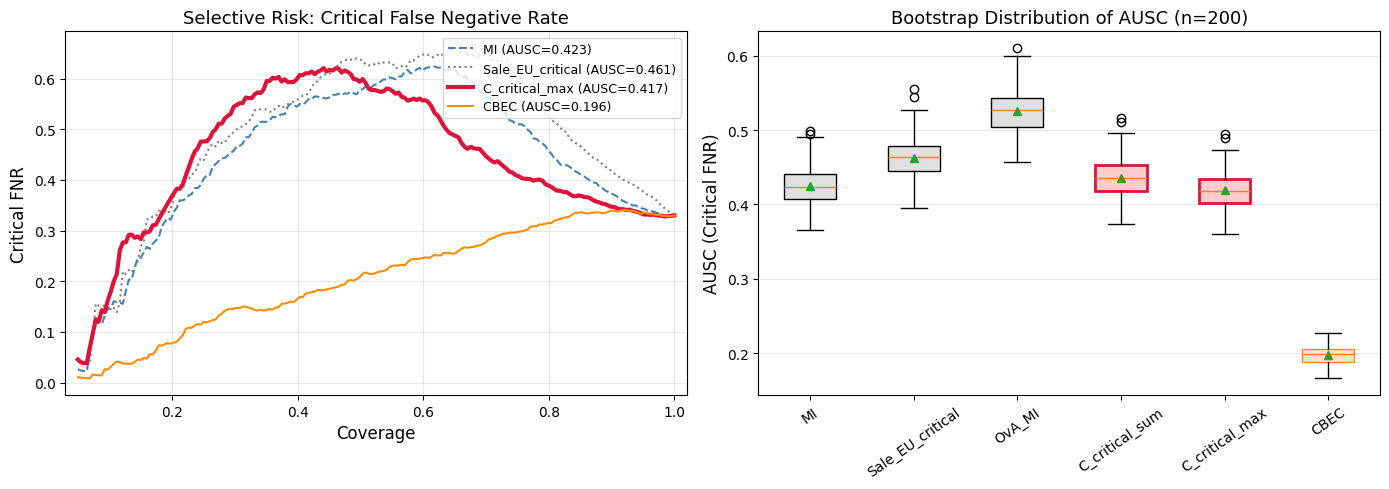

In [19]:
ausc_data = {}
for name, scores in mc_dropout_policies.items():
    ausc_fnr, covs, risks_fnr = compute_ausc(
        y_true_mc,
        mc_dropout_y_pred,
        scores,
        CRITICAL_CLASSES,
        metric='critical_fnr',
        n_points=200,
    )
    ausc_data[name] = {'fnr': ausc_fnr, 'covs': covs, 'risks_fnr': risks_fnr}

paper_methods = {
    'Scalar': [('MI', 'steelblue', '--')],
    'Per-class variance': [('Sale_EU_critical', 'gray', ':')],
    'Per-class C_k': [('C_critical_max', 'crimson', '-')],
    'Boundary-aware': [('Boundary_MI', 'purple', ':'), ('CBEC', 'darkorange', '-')],
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for _, methods in paper_methods.items():
    for name, color, ls in methods:
        if name in ausc_data:
            d = ausc_data[name]
            lw = 3.0 if name == 'C_critical_max' else 1.5
            ax.plot(d['covs'], d['risks_fnr'], color=color, linestyle=ls, linewidth=lw, label=f'{name} (AUSC={d["fnr"]:.3f})')

ax.set_xlabel('Coverage', fontsize=12)
ax.set_ylabel('Critical FNR', fontsize=12)
ax.set_title('Selective Risk: Critical False Negative Rate', fontsize=13)
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_xlim(0.03, 1.02)

ax = axes[1]
box_methods = ['MI', 'Sale_EU_critical', 'OvA_MI', 'Boundary_MI', 'C_critical_sum', 'C_critical_max', 'CBEC']
box_labels = [name for name in box_methods if name in boot_mc_dropout['ausc_samples']]
box_data = [boot_mc_dropout['ausc_samples'][name] for name in box_labels]

bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True, showmeans=True)
for patch, name in zip(bp['boxes'], box_labels):
    if 'C_critical' in name:
        patch.set_facecolor('#ffcccc')
        patch.set_edgecolor('crimson')
        patch.set_linewidth(2)
    elif name == 'CBEC':
        patch.set_facecolor('#ffe0cc')
        patch.set_edgecolor('darkorange')
    else:
        patch.set_facecolor('#e0e0e0')

ax.set_ylabel('AUSC (Critical FNR)', fontsize=12)
ax.set_title('Bootstrap Distribution of AUSC (n=200)', fontsize=13)
ax.tick_params(axis='x', rotation=35)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


In [20]:
print('=' * 80)
print('KEY NUMBERS FOR MC DROPOUT')
print('=' * 80)

best_name = sorted_mc_dropout[0][0]
best_ausc = sorted_mc_dropout[0][1]['mean']
best_ci = (sorted_mc_dropout[0][1]['ci_lower'], sorted_mc_dropout[0][1]['ci_upper'])

print(f'Best method: {best_name}')
print(f'AUSC (Crit FNR): {best_ausc:.4f} [95% CI: {best_ci[0]:.4f}, {best_ci[1]:.4f}]')
print(f'Wins: {boot_mc_dropout["ranking_stability"].get(best_name, 0) * 100:.1f}% of bootstrap samples')

if 'MI' in boot_mc_dropout['summary']:
    mi_ausc = boot_mc_dropout['summary']['MI']['mean']
    improvement_mi = (mi_ausc - best_ausc) / mi_ausc * 100
    print(f'Improvement over MI: {improvement_mi:.1f}%')

if 'Sale_EU_critical' in boot_mc_dropout['summary']:
    var_ausc = boot_mc_dropout['summary']['Sale_EU_critical']['mean']
    improvement_var = (var_ausc - best_ausc) / var_ausc * 100
    print(f'Improvement over Sale_EU_critical: {improvement_var:.1f}%')

if ('C_critical_max', 'MI') in boot_mc_dropout['pairwise_pvalues']:
    p_mi = boot_mc_dropout['pairwise_pvalues'][('C_critical_max', 'MI')]
    print(f'P(C_critical_max < MI): {p_mi:.3f}')

if best_name in boot_mc_dropout_80:
    b = boot_mc_dropout_80[best_name]
    print(f'At 80% coverage ({best_name}):')
    print(f'  Accuracy: {b["accuracy"]["mean"]:.4f} +/- {b["accuracy"]["std"]:.4f}')
    print(f'  Critical FNR: {b["critical_fnr"]["mean"]:.4f} +/- {b["critical_fnr"]["std"]:.4f}')
    print(f'  Macro F1: {b["f1_macro"]["mean"]:.4f} +/- {b["f1_macro"]["std"]:.4f}')


KEY NUMBERS FOR MC DROPOUT
Best method: CBEC
AUSC (Crit FNR): 0.1971 [95% CI: 0.1729, 0.2223]
Wins: 100.0% of bootstrap samples
Improvement over MI: 53.6%
Improvement over Sale_EU_critical: 57.4%
At 80% coverage (CBEC):
  Accuracy: 0.8668 +/- 0.0041
  Critical FNR: 0.3158 +/- 0.0149
  Macro F1: 0.5669 +/- 0.0090


## 8. Appendix Diagnostic Figures

Diagnostic figures for the appendix:
- **A1** Skewness reliability: why C_k degrades at Grade 3 under MC Dropout
- **A2** CBEC vs Entropy tradeoff: AUSC vs FNR@80% violin plots
- **A3** Entropy vs MI/C_k: aleatoric dominance under MC Dropout
- **A4** 1/μ_k normalisation benefit: C_crit_max vs Sale_EU_crit

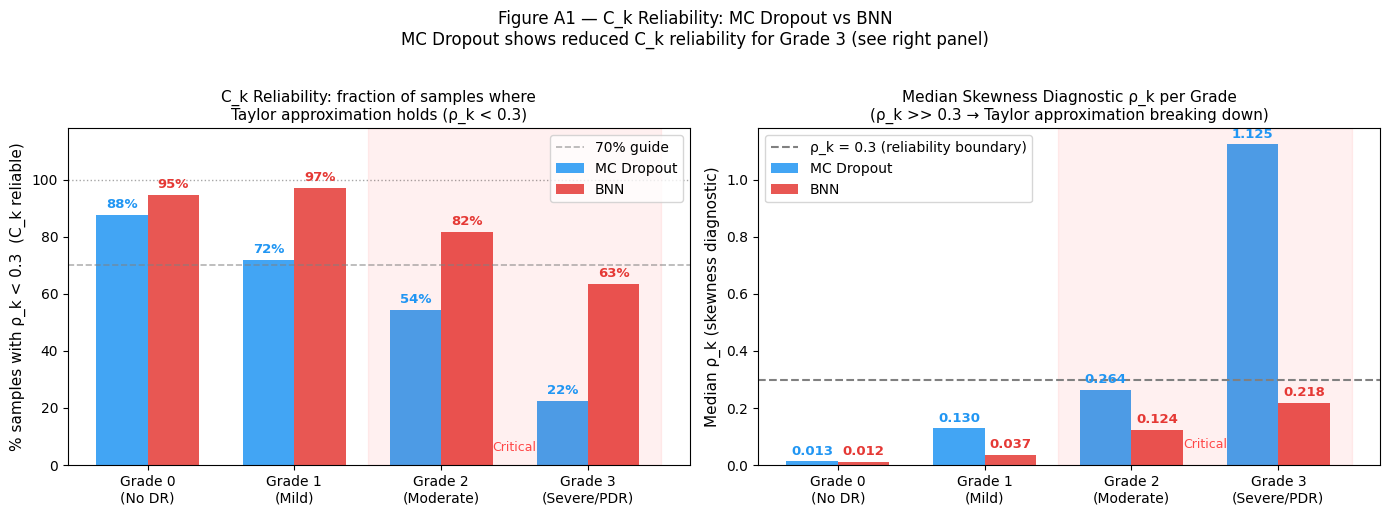

Skewness reliability summary:
Grade        MCDO reliable%   BNN reliable%   MCDO median ρ  BNN median ρ
--------------------------------------------------------------------
Grade 0              87.6%           94.7%          0.0133        0.0118
Grade 1              71.7%           97.0%          0.1296        0.0365
Grade 2              54.2%           81.6%          0.2642        0.1238
Grade 3              22.4%           63.4%          1.1246        0.2180


In [21]:
# ── Figure A1: Skewness Reliability per Grade — MCDO vs BNN ─────────────────
import matplotlib.patches as mpatches
from scipy import stats as scipy_stats

# Load BNN predictions and compute rho_k
bnn_preds_app  = np.load('results_bayesian/mc_predictions.npy')   # [30, 7948, 4]
bnn_ytrue_app  = np.load('results_bayesian/y_true.npy')
if bnn_ytrue_app.ndim > 1:
    bnn_ytrue_app = np.argmax(bnn_ytrue_app, axis=1)

bnn_m_app = compute_all_uncertainties(
    bnn_preds_app, critical_classes=CRITICAL_CLASSES, safe_classes=SAFE_CLASSES
)
bnn_rho_k = bnn_m_app['rho_k']    # [N, 4]
mcdo_rho_k = mc_dropout_metrics['rho_k']

THRESHOLD = 0.3
mcdo_reliable = [np.mean(mcdo_rho_k[:, k] < THRESHOLD) * 100 for k in range(4)]
bnn_reliable  = [np.mean(bnn_rho_k[:, k]  < THRESHOLD) * 100 for k in range(4)]
mcdo_median   = [np.median(mcdo_rho_k[:, k]) for k in range(4)]
bnn_median    = [np.median(bnn_rho_k[:, k])  for k in range(4)]

grade_labels = ['Grade 0\n(No DR)', 'Grade 1\n(Mild)',
                'Grade 2\n(Moderate)', 'Grade 3\n(Severe/PDR)']
MCDO_C = '#2196F3'; BNN_C = '#E53935'
x = np.arange(4); w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left — % reliable
ax = axes[0]
b1 = ax.bar(x - w/2, mcdo_reliable, w, color=MCDO_C, alpha=0.85, label='MC Dropout')
b2 = ax.bar(x + w/2, bnn_reliable,  w, color=BNN_C,  alpha=0.85, label='BNN')
ax.axhline(100, color='k', ls=':', lw=1, alpha=0.35)
ax.axhline(70,  color='gray', ls='--', lw=1.2, alpha=0.6, label='70% guide')
for bar, val, c in [(b1, mcdo_reliable, MCDO_C), (b2, bnn_reliable, BNN_C)]:
    for b, v in zip(bar, val):
        ax.text(b.get_x() + b.get_width()/2, v + 1.5,
                f'{v:.0f}%', ha='center', va='bottom', fontsize=9.5,
                color=c, fontweight='bold')
ax.axvspan(1.5, 3.5, alpha=0.06, color='red')
ax.text(2.5, 5, 'Critical', ha='center', fontsize=9, color='red', alpha=0.7)
ax.set_xticks(x); ax.set_xticklabels(grade_labels, fontsize=10)
ax.set_ylabel('% samples with ρ_k < 0.3  (C_k reliable)', fontsize=11)
ax.set_title('C_k Reliability: fraction of samples where\nTaylor approximation holds (ρ_k < 0.3)', fontsize=11)
ax.legend(fontsize=10); ax.set_ylim(0, 118)

# Right — median ρ_k
ax = axes[1]
b1 = ax.bar(x - w/2, mcdo_median, w, color=MCDO_C, alpha=0.85, label='MC Dropout')
b2 = ax.bar(x + w/2, bnn_median,  w, color=BNN_C,  alpha=0.85, label='BNN')
ax.axhline(0.3, color='gray', ls='--', lw=1.5, label='ρ_k = 0.3 (reliability boundary)')
for bar, val, c in [(b1, mcdo_median, MCDO_C), (b2, bnn_median, BNN_C)]:
    for b, v in zip(bar, val):
        ax.text(b.get_x() + b.get_width()/2, v + 0.012,
                f'{v:.3f}', ha='center', va='bottom', fontsize=9.5,
                color=c, fontweight='bold')
ax.axvspan(1.5, 3.5, alpha=0.06, color='red')
ax.text(2.5, ax.get_ylim()[1]*0.05 if ax.get_ylim()[1] > 0 else 0.05,
        'Critical', ha='center', fontsize=9, color='red', alpha=0.7)
ax.set_xticks(x); ax.set_xticklabels(grade_labels, fontsize=10)
ax.set_ylabel('Median ρ_k (skewness diagnostic)', fontsize=11)
ax.set_title('Median Skewness Diagnostic ρ_k per Grade\n'
             '(ρ_k >> 0.3 → Taylor approximation breaking down)', fontsize=11)
ax.legend(fontsize=10)

fig.suptitle('Figure A1 — C_k Reliability: MC Dropout vs BNN\n'
             'MC Dropout shows reduced C_k reliability for Grade 3 (see right panel)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print('Skewness reliability summary:')
print(f'{"Grade":<10} {"MCDO reliable%":>16} {"BNN reliable%":>15} '
      f'{"MCDO median ρ":>15} {"BNN median ρ":>13}')
print('-' * 68)
for k in range(4):
    print(f'Grade {k}    {mcdo_reliable[k]:>14.1f}%  {bnn_reliable[k]:>13.1f}%  '
          f'{mcdo_median[k]:>14.4f}  {bnn_median[k]:>12.4f}')


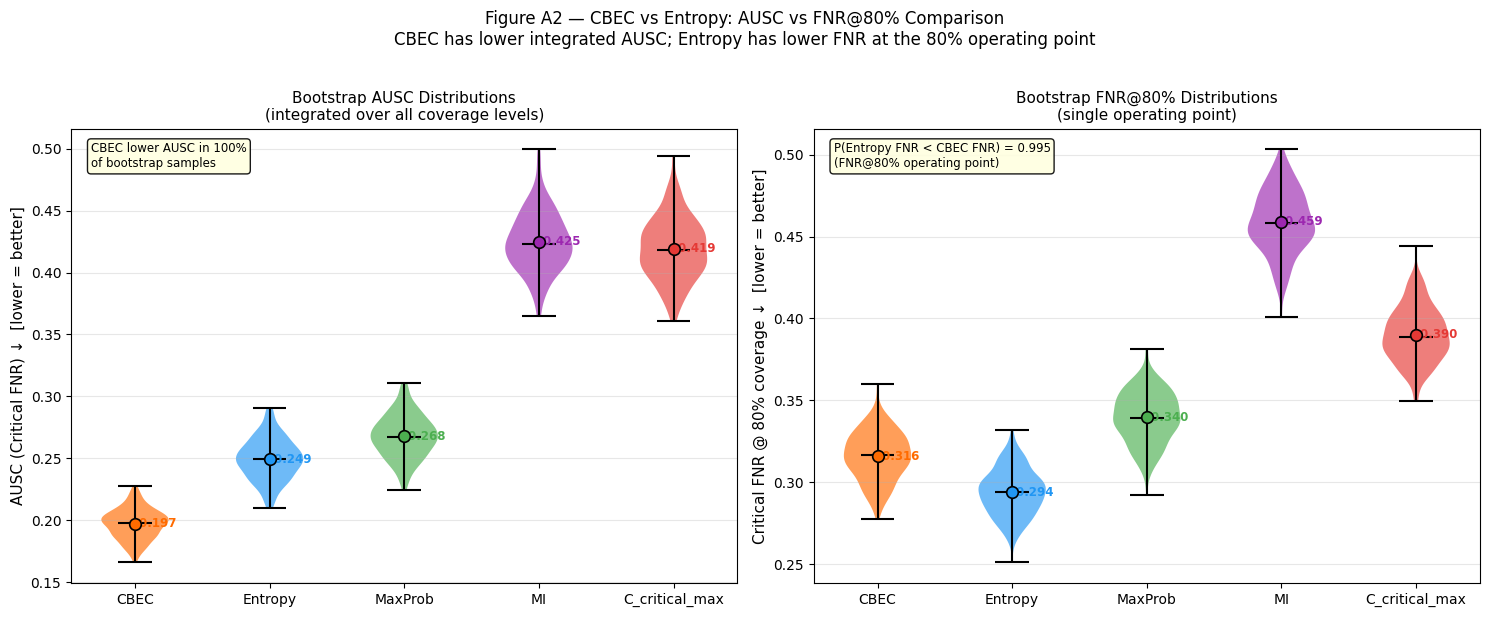

In [22]:
# ── Figure A2: CBEC vs Entropy — AUSC vs FNR@80% Tradeoff ───────────────────
# Recompute FNR@80% bootstrap with stored samples
boot_fnr_samples = bootstrap_selective_prediction_with_samples(
    y_true=y_true_mc,
    y_pred=mc_dropout_y_pred,
    uncertainty_scores_dict=mc_dropout_policies,
    coverage=0.80,
    critical_classes=CRITICAL_CLASSES,
    n_bootstrap=200,
    seed=42,
)

focus_methods = ['CBEC', 'Entropy', 'MaxProb', 'MI', 'C_critical_max']
method_colors = {
    'CBEC':           '#FF6B00',
    'Entropy':        '#2196F3',
    'MaxProb':        '#4CAF50',
    'MI':             '#9C27B0',
    'C_critical_max': '#E53935',
}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

def violin_panel(ax, data_list, labels, colors, ylabel, title, note):
    vp = ax.violinplot(data_list, positions=np.arange(len(labels)),
                       showmedians=True, showextrema=True)
    for body, c in zip(vp['bodies'], colors):
        body.set_facecolor(c); body.set_alpha(0.65)
    for part in ['cbars', 'cmins', 'cmaxes', 'cmedians']:
        vp[part].set_color('black'); vp[part].set_linewidth(1.5)
    for i, (samples, c) in enumerate(zip(data_list, colors)):
        mn = np.nanmean(samples)
        ax.scatter(i, mn, color=c, s=70, zorder=5, edgecolors='black', lw=1.2)
        ax.text(i, mn, f' {mn:.3f}', ha='left', va='center', fontsize=8.5,
                fontweight='bold', color=c)
    ax.set_xticks(np.arange(len(labels))); ax.set_xticklabels(labels, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=11); ax.set_title(title, fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    ax.text(0.03, 0.97, note, transform=ax.transAxes, va='top', fontsize=8.5,
            bbox=dict(boxstyle='round', fc='lightyellow', alpha=0.9))

# Left — AUSC
ausc_data_v  = [boot_mc_dropout['ausc_samples'][m] for m in focus_methods]
ausc_colors  = [method_colors[m] for m in focus_methods]
violin_panel(axes[0], ausc_data_v, focus_methods, ausc_colors,
             'AUSC (Critical FNR) ↓  [lower = better]',
             'Bootstrap AUSC Distributions\n(integrated over all coverage levels)',
             'CBEC lower AUSC in 100%\nof bootstrap samples')

# Right — FNR@80%
fnr_data_v  = [boot_fnr_samples[m]['critical_fnr']['samples'][
                   np.isfinite(boot_fnr_samples[m]['critical_fnr']['samples'])]
               for m in focus_methods]
violin_panel(axes[1], fnr_data_v, focus_methods, ausc_colors,
             'Critical FNR @ 80% coverage ↓  [lower = better]',
             'Bootstrap FNR@80% Distributions\n(single operating point)',
             'P(Entropy FNR < CBEC FNR) = 0.995\n(FNR@80% operating point)')

fig.suptitle('Figure A2 — CBEC vs Entropy: AUSC vs FNR@80% Comparison\n'
             'CBEC has lower integrated AUSC; Entropy has lower FNR at the 80% operating point',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


/tmp/ipykernel_3999072/1649186582.py:70: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(list(groups_ep.values()), labels=list(groups_ep.keys()),


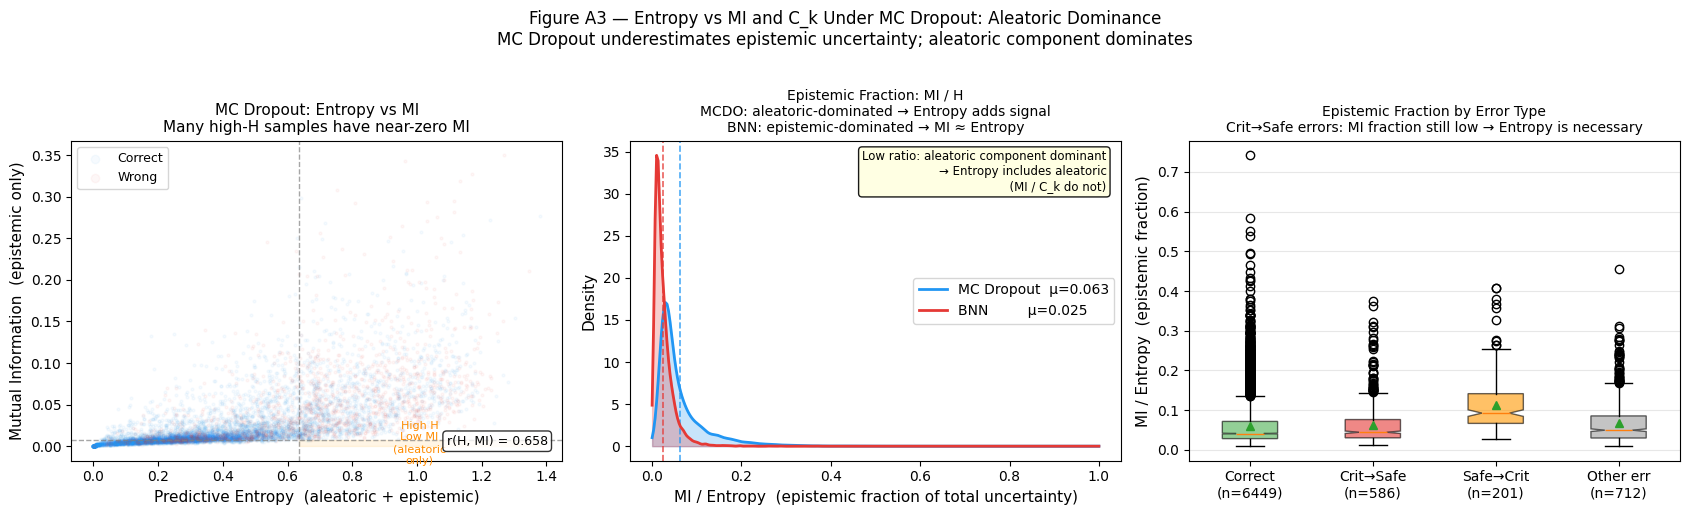

Mean epistemic fraction — MCDO: 0.063  |  BNN: 0.025
r(Entropy, MI) for MCDO: 0.6583  (weak coupling → Entropy adds info beyond MI)


In [23]:
# ── Figure A3: Entropy vs MI and C_k Under MC Dropout ───────────────────────
from scipy.stats import gaussian_kde

entropy_sc = mc_dropout_metrics['entropy']
mi_sc      = mc_dropout_metrics['MI']
correct_m  = mc_dropout_y_pred == y_true_mc

# Epistemic fraction: how much of total uncertainty is epistemic?
ep_frac_mcdo = np.clip(mi_sc / (entropy_sc + 1e-10), 0, 1)
ep_frac_bnn  = np.clip(bnn_m_app['MI'] / (bnn_m_app['entropy'] + 1e-10), 0, 1)

crit_mask = np.isin(y_true_mc, CRITICAL_CLASSES)
crit2safe = crit_mask & np.isin(mc_dropout_y_pred, SAFE_CLASSES)
safe2crit = ~crit_mask & np.isin(mc_dropout_y_pred, CRITICAL_CLASSES)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# ── Left: Entropy vs MI scatter ───────────────────────────────────────────────
ax = axes[0]
ax.scatter(entropy_sc[correct_m],  mi_sc[correct_m],
           alpha=0.04, s=4, color='#2196F3', label='Correct')
ax.scatter(entropy_sc[~correct_m], mi_sc[~correct_m],
           alpha=0.04, s=4, color='#E53935', label='Wrong')
# Annotate aleatoric-only zone
h75 = np.percentile(entropy_sc, 75); mi25 = np.percentile(mi_sc, 25)
ax.axhline(mi25, color='gray', ls='--', lw=1, alpha=0.7)
ax.axvline(h75,  color='gray', ls='--', lw=1, alpha=0.7)
ax.fill_betweenx([0, mi25], h75, entropy_sc.max(),
                 alpha=0.10, color='orange')
ax.text((h75 + entropy_sc.max())/2, mi25/2,
        'High H\nLow MI\n(aleatoric\nonly)',
        ha='center', va='center', fontsize=8, color='darkorange')
r_h_mi, _ = scipy_stats.pearsonr(entropy_sc, mi_sc)
ax.text(0.97, 0.05, f'r(H, MI) = {r_h_mi:.3f}',
        transform=ax.transAxes, ha='right', fontsize=9,
        bbox=dict(boxstyle='round', fc='white', alpha=0.8))
ax.set_xlabel('Predictive Entropy  (aleatoric + epistemic)', fontsize=11)
ax.set_ylabel('Mutual Information  (epistemic only)', fontsize=11)
ax.set_title('MC Dropout: Entropy vs MI\nMany high-H samples have near-zero MI', fontsize=11)
ax.legend(fontsize=9, markerscale=3)

# ── Middle: Epistemic fraction MCDO vs BNN ────────────────────────────────────
ax = axes[1]
xs = np.linspace(0, 1, 300)
for ep_frac, color, name in [(ep_frac_mcdo, '#2196F3', f'MC Dropout  μ={ep_frac_mcdo.mean():.3f}'),
                              (ep_frac_bnn,  '#E53935', f'BNN         μ={ep_frac_bnn.mean():.3f}')]:
    ax.fill_between(xs, gaussian_kde(ep_frac)(xs), alpha=0.25, color=color)
    ax.plot(xs, gaussian_kde(ep_frac)(xs), color=color, lw=2, label=name)
    ax.axvline(ep_frac.mean(), color=color, ls='--', lw=1.2, alpha=0.8)
ax.set_xlabel('MI / Entropy  (epistemic fraction of total uncertainty)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Epistemic Fraction: MI / H\n'
             'MCDO: aleatoric-dominated → Entropy adds signal\n'
             'BNN: epistemic-dominated → MI ≈ Entropy', fontsize=10)
ax.legend(fontsize=10)
ax.text(0.97, 0.97,
        'Low ratio: aleatoric component dominant\n→ Entropy includes aleatoric\n  (MI / C_k do not)',
        transform=ax.transAxes, ha='right', va='top', fontsize=8.5,
        bbox=dict(boxstyle='round', fc='lightyellow', alpha=0.9))

# ── Right: Epistemic fraction by error type ───────────────────────────────────
ax = axes[2]
other_err = ~correct_m & ~crit2safe & ~safe2crit
groups_ep = {
    f'Correct\n(n={correct_m.sum()})':     ep_frac_mcdo[correct_m],
    f'Crit→Safe\n(n={crit2safe.sum()})':   ep_frac_mcdo[crit2safe],
    f'Safe→Crit\n(n={safe2crit.sum()})':   ep_frac_mcdo[safe2crit],
    f'Other err\n(n={other_err.sum()})':   ep_frac_mcdo[other_err],
}
bp = ax.boxplot(list(groups_ep.values()), labels=list(groups_ep.keys()),
                patch_artist=True, notch=True, showmeans=True)
for patch, c in zip(bp['boxes'], ['#4CAF50', '#E53935', '#FF9800', '#9E9E9E']):
    patch.set_facecolor(c); patch.set_alpha(0.6)
ax.set_ylabel('MI / Entropy  (epistemic fraction)', fontsize=11)
ax.set_title('Epistemic Fraction by Error Type\n'
             'Crit→Safe errors: MI fraction still low → Entropy is necessary', fontsize=10)
ax.grid(axis='y', alpha=0.3)

fig.suptitle('Figure A3 — Entropy vs MI and C_k Under MC Dropout: Aleatoric Dominance\n'
             'MC Dropout underestimates epistemic uncertainty; aleatoric component dominates',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print(f'Mean epistemic fraction — MCDO: {ep_frac_mcdo.mean():.3f}  |  BNN: {ep_frac_bnn.mean():.3f}')
print(f'r(Entropy, MI) for MCDO: {r_h_mi:.4f}  (weak coupling → Entropy adds info beyond MI)')


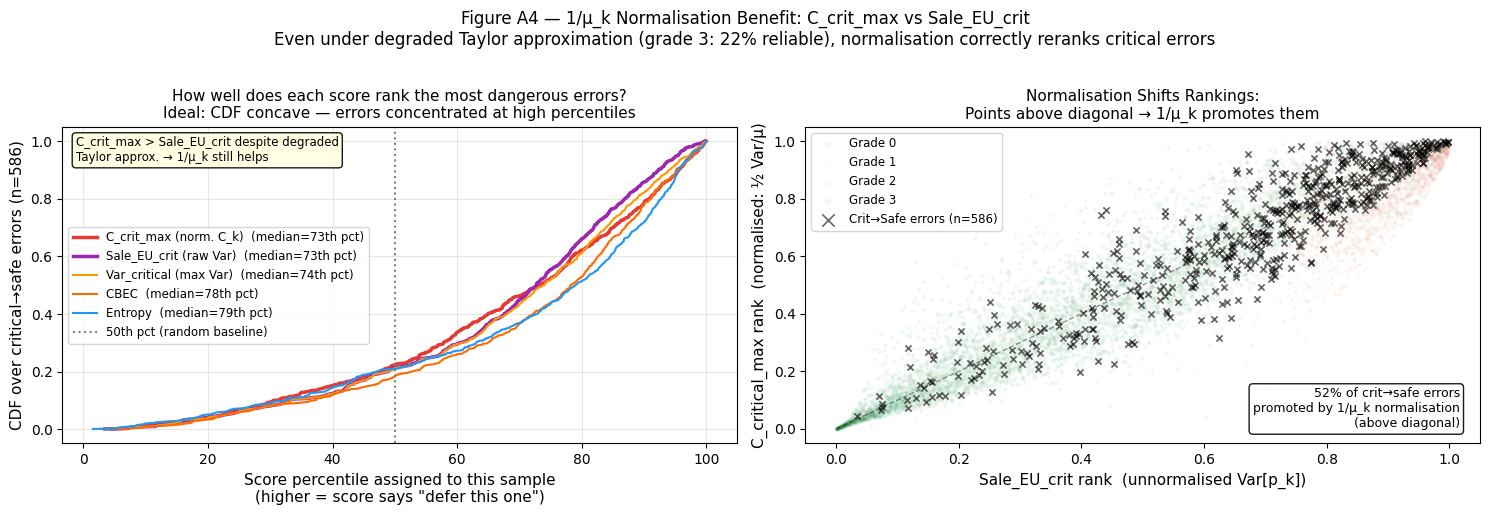


Median percentile rank of crit→safe errors (higher = score detects them better):
  C_crit_max (norm. C_k)               73.3th percentile
  Sale_EU_crit (raw Var)               72.7th percentile
  Var_critical (max Var)               74.0th percentile
  CBEC                                 78.3th percentile
  Entropy                              79.0th percentile


In [24]:
# ── Figure A4: 1/μ_k Normalisation Benefit — C_crit_max vs Sale_EU_crit ──────
crit_mask_a4 = np.isin(y_true_mc, CRITICAL_CLASSES)
crit2safe_a4 = crit_mask_a4 & np.isin(mc_dropout_y_pred, SAFE_CLASSES)

compare_scores = {
    'C_crit_max\n(norm. C_k)':  mc_dropout_policies['C_critical_max'],
    'Sale_EU_crit\n(raw Var)':   mc_dropout_policies['Sale_EU_critical'],
    'Var_critical\n(max Var)':   mc_dropout_policies['Var_critical'],
    'CBEC':                       mc_dropout_policies['CBEC'],
    'Entropy':                    mc_dropout_policies['Entropy'],
}
score_colors = ['#E53935', '#9C27B0', '#FF9800', '#FF6B00', '#2196F3']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Left: CDF of percentile ranks for crit→safe errors ───────────────────────
ax = axes[0]
for (name, scores), color in zip(compare_scores.items(), score_colors):
    ranks = scipy_stats.rankdata(scores) / len(scores) * 100
    pct   = ranks[crit2safe_a4]
    sv    = np.sort(pct)
    cdf   = np.arange(1, len(sv) + 1) / len(sv)
    med   = np.median(pct)
    lw    = 2.5 if 'C_crit_max' in name or 'Sale_EU' in name else 1.5
    ax.plot(sv, cdf, color=color, lw=lw,
            label=f'{name.replace(chr(10), " ")}  (median={med:.0f}th pct)')

ax.axvline(50, color='gray', ls=':', lw=1.5, label='50th pct (random baseline)')
ax.set_xlabel('Score percentile assigned to this sample\n'
              '(higher = score says "defer this one")', fontsize=11)
ax.set_ylabel(f'CDF over critical→safe errors (n={crit2safe_a4.sum()})', fontsize=11)
ax.set_title('How well does each score rank the most dangerous errors?\n'
             'Ideal: CDF concave — errors concentrated at high percentiles', fontsize=11)
ax.legend(fontsize=8.5)
ax.grid(alpha=0.3)
ax.text(0.02, 0.97,
        'C_crit_max > Sale_EU_crit despite degraded\nTaylor approx. → 1/μ_k still helps',
        transform=ax.transAxes, va='top', fontsize=8.5,
        bbox=dict(boxstyle='round', fc='lightyellow', alpha=0.9))

# ── Right: Rank scatter C_crit_max vs Sale_EU_crit ───────────────────────────
ax = axes[1]
cc_rank   = scipy_stats.rankdata(mc_dropout_policies['C_critical_max']) / len(y_true_mc)
sale_rank = scipy_stats.rankdata(mc_dropout_policies['Sale_EU_critical']) / len(y_true_mc)
class_colors_s = ['#1a9850', '#fee08b', '#f46d43', '#d73027']

for k in range(4):
    mk = y_true_mc == k
    ax.scatter(sale_rank[mk], cc_rank[mk],
               alpha=0.04, s=4, color=class_colors_s[k], label=f'Grade {k}')

ax.scatter(sale_rank[crit2safe_a4], cc_rank[crit2safe_a4],
           alpha=0.6, s=20, color='black', marker='x', lw=1.2, zorder=5,
           label=f'Crit→Safe errors (n={crit2safe_a4.sum()})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.4)

promoted = np.mean(cc_rank[crit2safe_a4] > sale_rank[crit2safe_a4]) * 100
ax.text(0.97, 0.05,
        f'{promoted:.0f}% of crit→safe errors\npromoted by 1/μ_k normalisation\n'
        f'(above diagonal)',
        transform=ax.transAxes, ha='right', fontsize=9,
        bbox=dict(boxstyle='round', fc='white', alpha=0.9))
ax.set_xlabel('Sale_EU_crit rank  (unnormalised Var[p_k])', fontsize=11)
ax.set_ylabel('C_critical_max rank  (normalised: ½ Var/μ)', fontsize=11)
ax.set_title('Normalisation Shifts Rankings:\nPoints above diagonal → 1/μ_k promotes them', fontsize=11)
ax.legend(fontsize=8.5, markerscale=2)

fig.suptitle(f'Figure A4 — 1/μ_k Normalisation Benefit: C_crit_max vs Sale_EU_crit\n'
             f'Even under degraded Taylor approximation (grade 3: {mcdo_reliable[3]:.0f}% reliable), '
             'normalisation correctly reranks critical errors', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print('\nMedian percentile rank of crit→safe errors (higher = score detects them better):')
for name, scores in compare_scores.items():
    ranks = scipy_stats.rankdata(scores) / len(scores) * 100
    med   = np.median(ranks[crit2safe_a4])
    print(f'  {name.replace(chr(10)," "):<35}  {med:.1f}th percentile')
